# 📊 Customer Churn Analysis Project
---


## 🔹 1️⃣ Business Understanding
---

### 🎯 Objective
* Understand the key factors driving customer churn.
* Provide actionable insights and recommendations to stakeholders.

## 🔹 2️⃣ Data Overview
---

### 📌 Dataset Information

In [1]:
## Import Libraries & Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure pandas displays all columns when printing DataFrames
pd.set_option('display.max_columns', None)

# Load the dataset
df = pd.read_csv(r"D:\mohamed\DMP\project churn\WA_Fn-UseC_-Telco-Customer-Churn - WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
## Display First 5 Rows
df.head(5)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
## Check Dataset Shape (Rows & Columns)
df.shape


(7043, 21)

In [4]:
## Check Data Types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [5]:
## Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
## Statistical Summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
# Summarize categorical columns
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [8]:
## Check Missing Values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
## Display Unique Values per Categorical Column (exclude customerID)
for col in df.select_dtypes(include=['object']).columns:
    if col != 'customerID':
        print(f"Column: {col}")
        print(df[col].unique())
        print("-" * 50)

Column: gender
['Female' 'Male']
--------------------------------------------------
Column: Partner
['Yes' 'No']
--------------------------------------------------
Column: Dependents
['No' 'Yes']
--------------------------------------------------
Column: PhoneService
['No' 'Yes']
--------------------------------------------------
Column: MultipleLines
['No phone service' 'No' 'Yes']
--------------------------------------------------
Column: InternetService
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
Column: OnlineSecurity
['No' 'Yes' 'No internet service']
--------------------------------------------------
Column: OnlineBackup
['Yes' 'No' 'No internet service']
--------------------------------------------------
Column: DeviceProtection
['No' 'Yes' 'No internet service']
--------------------------------------------------
Column: TechSupport
['No' 'Yes' 'No internet service']
--------------------------------------------------
Column: StreamingTV
['No' 'Y

## 🔹 3️⃣ Data Cleaning
---

### 🧹 3.1 Remove Duplicates
* Check for duplicated records
* Drop duplicates if found

In [10]:
# Check the total number of duplicated rows
duplicates_count = df.duplicated().sum()
print(f"Number of duplicated records: {duplicates_count}")

Number of duplicated records: 0


### 🔄 3.2 Fix Data Types
* Convert incorrect data types for the purpose of this analysis
* Format the target variable (`Churn`) for correlation analysis

In [11]:
# Convert 'SeniorCitizen' from numeric (0/1) to text ('No'/'Yes')
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [12]:
# Extract numerical features for correlation analysis
correlation_df = df.select_dtypes(include=['number']).copy()

# Encode target variable 'Churn' as binary (1/0)
correlation_df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

correlation_df

,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,1
3,45,42.30,1840.75,0
4,2,70.70,151.65,1
...,...,...,...,...
7038,24,84.80,1990.50,0
7039,72,103.20,7362.90,0
7040,11,29.60,346.45,0
7041,4,74.40,306.60,1


### 🔍 3.3 Missing Values
* Check missing values
* Handle numerical missing values
* Handle categorical missing values

In [13]:
## Dataset size before cleaning
original_rows = df.shape[0]
original_cols = df.shape[1]

print("Before Cleaning:")
print("Rows:", original_rows)
print("Columns:", original_cols)

Before Cleaning:
Rows: 7043
Columns: 21


In [14]:
## Check Missing Values
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


## ✅ Data Cleaning Summary 

**1. Duplicates Removal:**
- Checked for duplicated records across the dataset. 
- Found **0 duplicates**, meaning no rows needed to be dropped.

**2. Data Type Formatting:**
- Mapped `SeniorCitizen` values from (0/1) to ('No'/'Yes') to maintain consistency with other categorical features.
- Isolated numerical columns and formatted the target variable (`Churn`) into binary values (1/0) in a dedicated dataframe to prepare for correlation analysis.

**3. Missing Values Handling:**
- The **TotalCharges** column contained **11 missing values**.
- These missing values could not be imputed using the formula **Tenure × MonthlyCharges** because the tenure value was **0**, making the calculation invalid.
- Therefore, the **11 rows with missing numerical values were removed** to maintain data integrity.
- No missing values were found in categorical features, so no categorical imputation was required.

## 📊 Exploratory Data Analysis (EDA)

In this EDA, we analyze all features in the dataset in a structured way.

First, we drop the `customerID` column because it is only an identifier and does not provide analytical value.

Then, we categorize the remaining features into three main groups:

- **Demographics**
- **Services**
- **Account Information**

This categorization helps us analyze the data systematically and gain clearer insights from each feature group.

#### ==========================================
#### --- 0. Target Variable (Churn) Overview ---
#### ==========================================

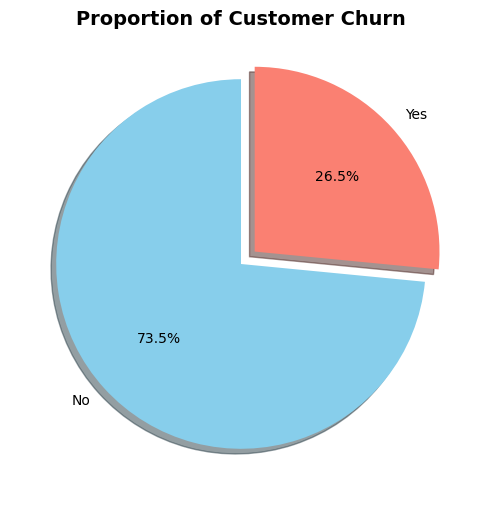

In [15]:
plt.figure(figsize=(6, 6))

# Count the values
churn_counts = df['Churn'].value_counts()

# Create a pie chart
plt.pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    colors=['skyblue', 'salmon'], 
    startangle=90, 
    explode=(0, 0.1), # Highlight the 'Yes' slice slightly
    shadow=True
)

plt.title('Proportion of Customer Churn', fontsize=14, fontweight='bold')
plt.show()

### 🎯 Target Variable Overview  

The distribution of the target variable shows that **26.5% of customers have churned**, while the majority remained active.  
This indicates a **moderate class imbalance**, where non-churn customers significantly outnumber churned customers.

In [16]:
# Drop customerID as it's not useful for EDA
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

In [17]:
# Categorize columns for easier plotting
demographic_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
services_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
account_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

### 1️⃣ Univariate Analysis
Exploring the distribution of each feature individually.

#### ==========================================
#### --- 1. Demographics Distribution ---
#### ==========================================

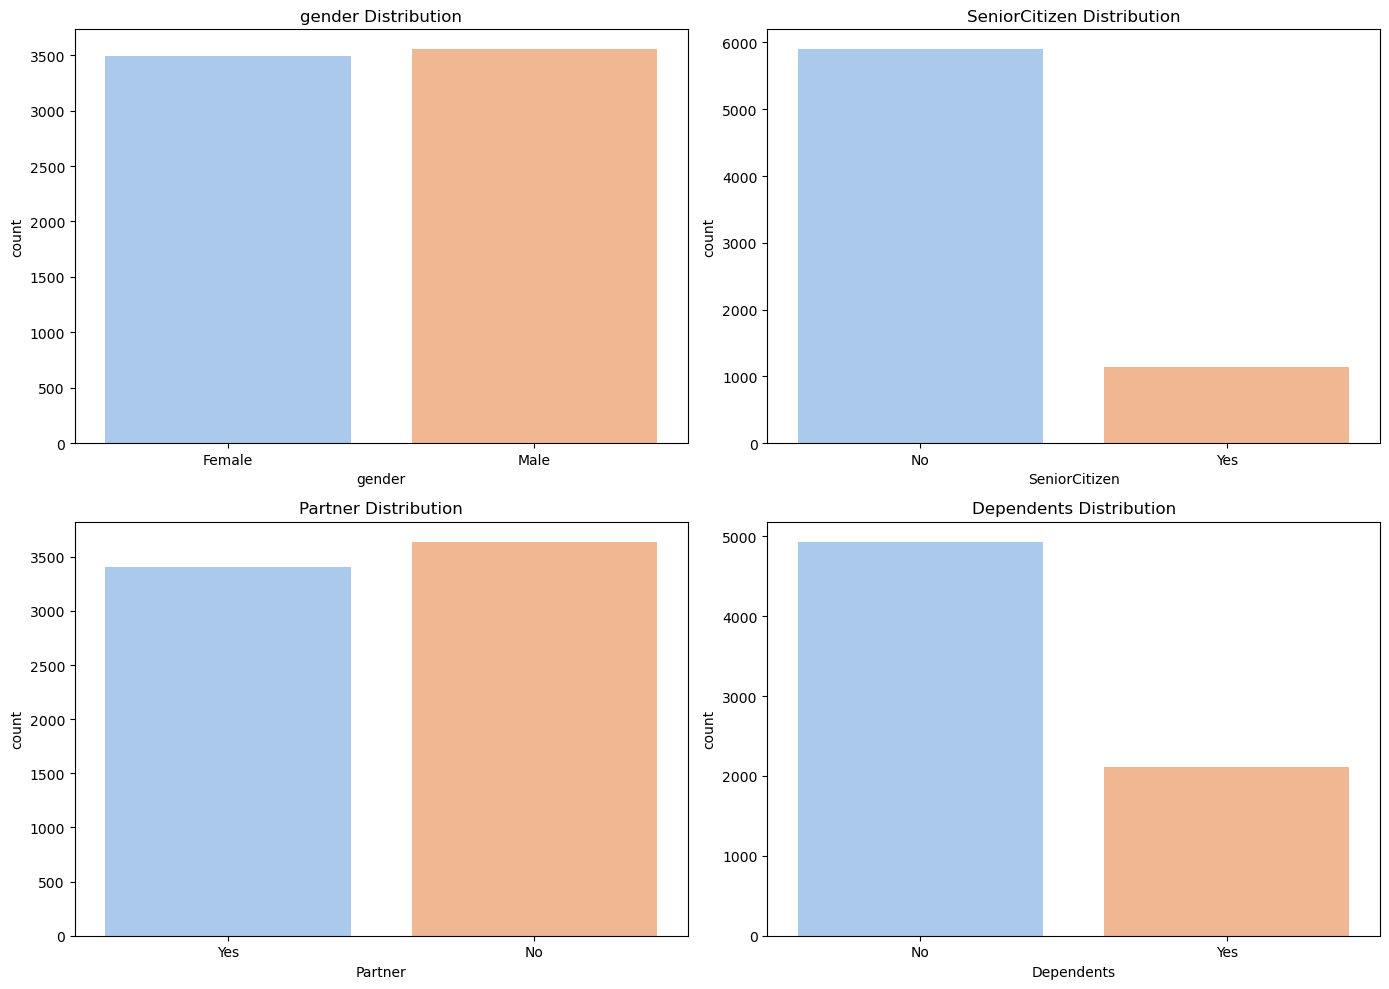

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(demographic_cols):
    r, c = i // 2, i % 2
    sns.countplot(
        data=df, x=col, hue=col,
        ax=axes[r, c], palette='pastel', legend=False
    ).set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

**1. Demographics (`gender`, `SeniorCitizen`, `Partner`, `Dependents`)**
* `gender` is perfectly balanced. 
* Most customers are not `SeniorCitizen`s.
* Customers are somewhat evenly split between having a `Partner` or not, but most do not have `Dependents`.

#### ==========================================
#### --- 2. Services Distribution ---
#### ==========================================

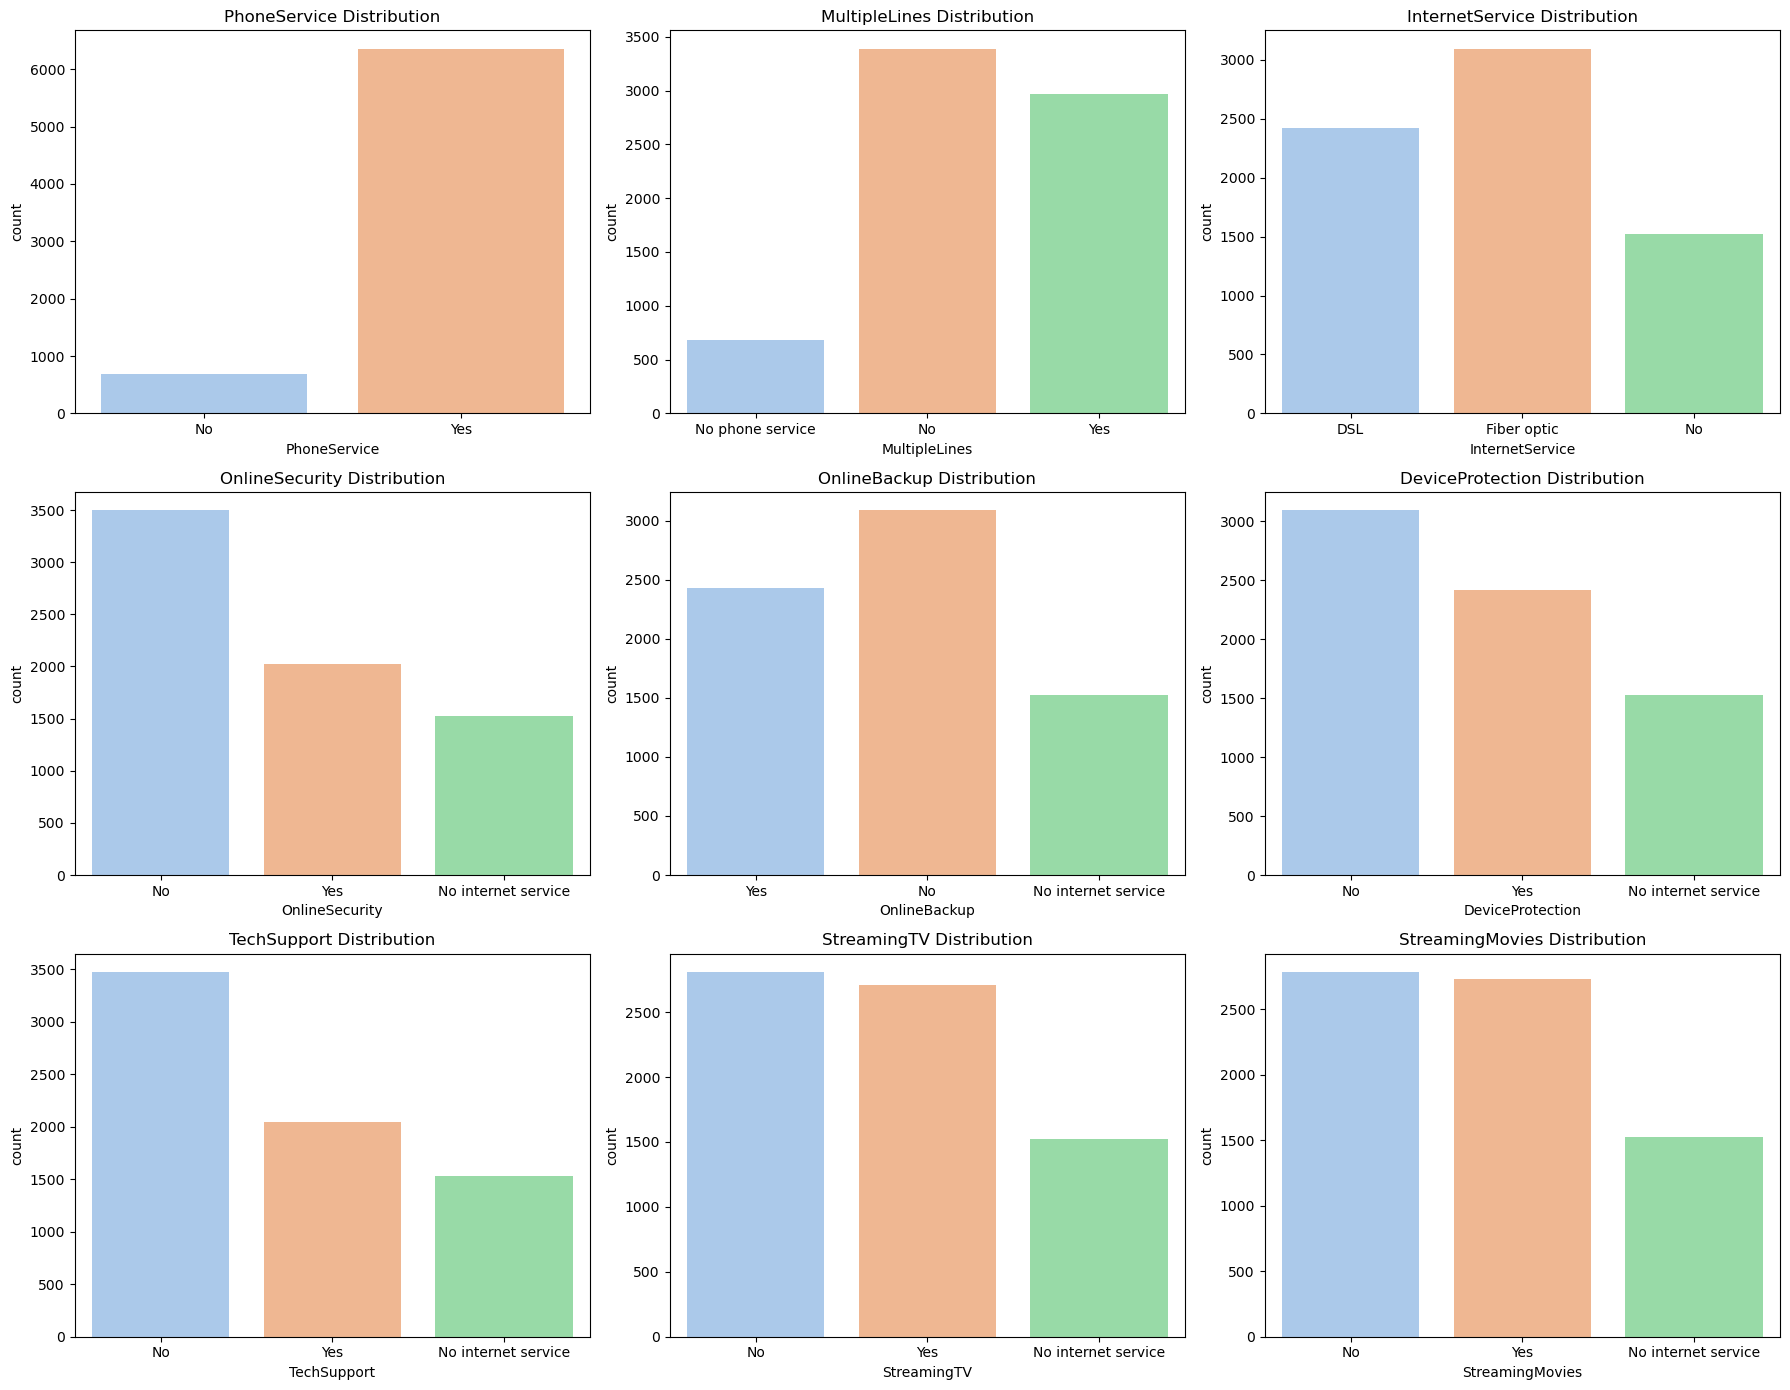

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for i, col in enumerate(services_cols):
    r, c = i // 3, i % 3
    sns.countplot(
        data=df, x=col, hue=col,
        ax=axes[r, c], palette='pastel', legend=False
    ).set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

**2. Services Subscribed**
* Most customers have `PhoneService`.
* `Fiber optic` is the most popular internet service.
* A significant number of customers with internet do *not* have additional services like `OnlineSecurity`, `TechSupport`, or `OnlineBackup`.
* Streaming services are quite popular among internet users.

#### ==========================================
#### --- 3. Account Information Distribution ---
#### ==========================================


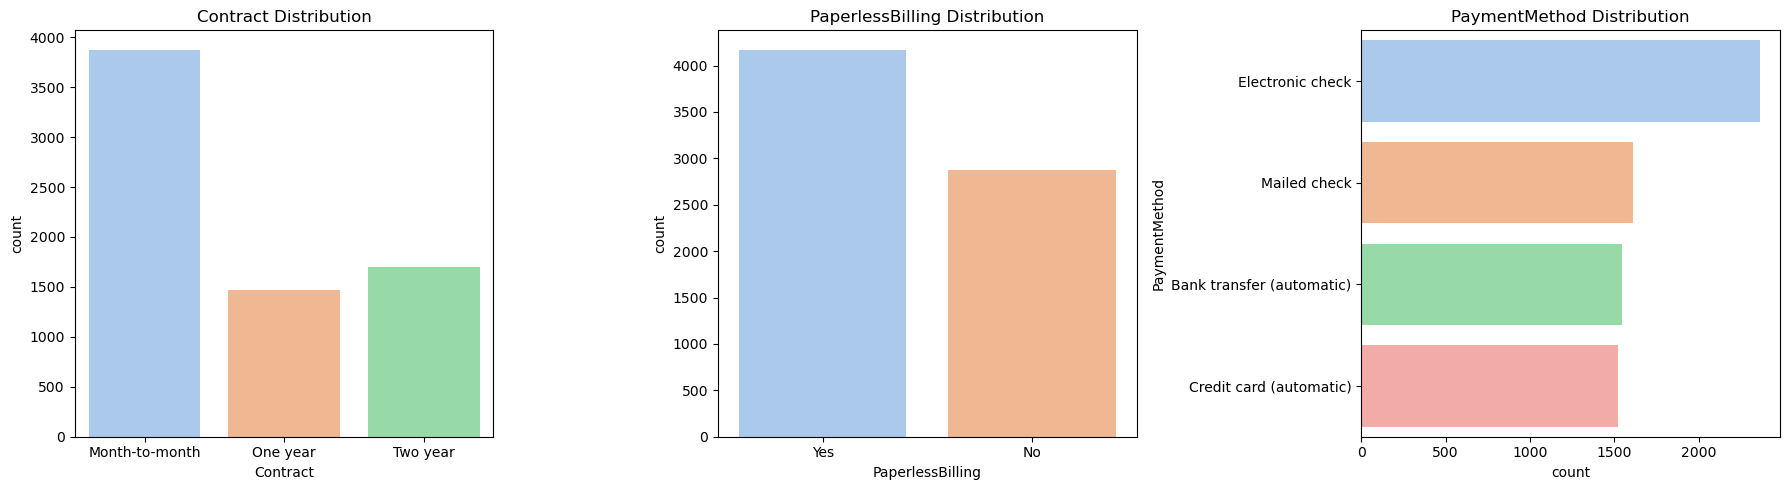

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(account_cols):
    # For PaymentMethod, we will put it on y-axis to avoid overlapping labels
    if col == 'PaymentMethod':
        sns.countplot(
            data=df, y=col, hue=col,
            ax=axes[i], palette='pastel', legend=False
        ).set_title(f'{col} Distribution')
    else:
        sns.countplot(
            data=df, x=col, hue=col,
            ax=axes[i], palette='pastel', legend=False
        ).set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

**3. Account Information**
* `Month-to-month` is the most common `Contract` type.
* Most customers use `PaperlessBilling`.
* `Electronic check` is the most used `PaymentMethod`.

### 4️⃣ Numerical Variables Analysis

In [21]:
# Select numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

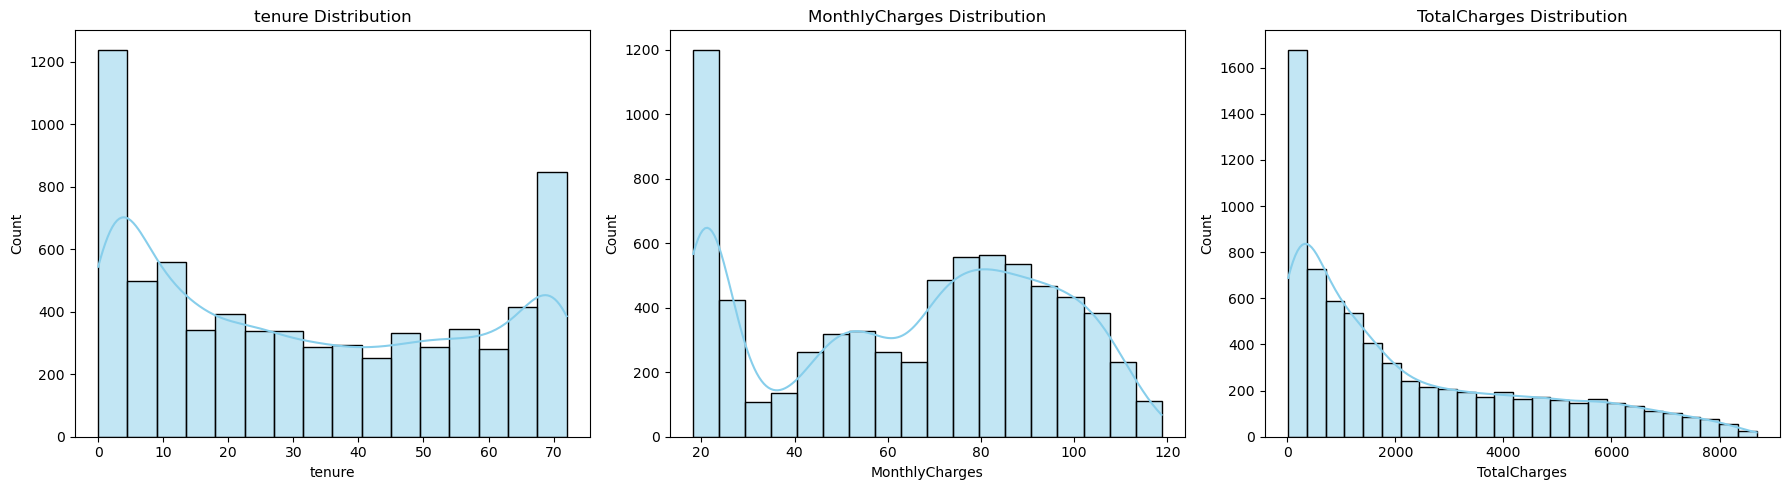

In [22]:
ig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df, x=col, kde=True, 
        color='skyblue', ax=axes[i]
    ).set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

* `tenure`: The distribution is bimodal. Many customers are very new (1-2 months), while another large group consists of highly loyal customers (70+ months).
* `MonthlyCharges`: A massive group pays the minimum base fee (~$20), while the rest are distributed mostly between $60 and $110.
* `TotalCharges`: Skewed to the right, mostly because new customers have not accumulated large charges yet.

### 2️⃣ Bivariate Analysis (Features vs Churn)
Analyzing how each feature impacts the target variable (`Churn`).

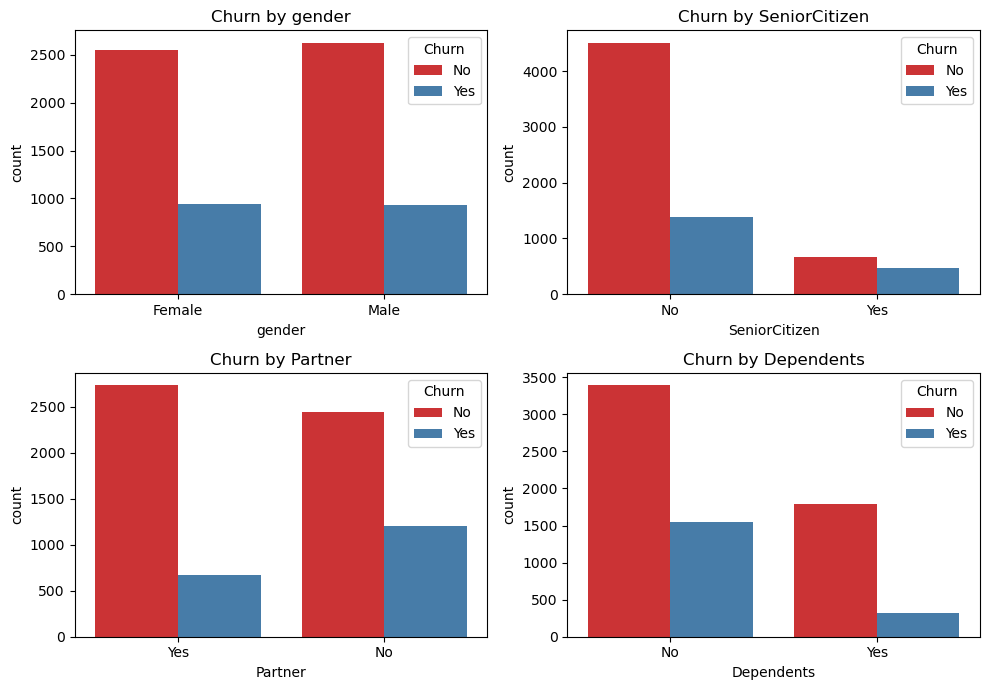

In [23]:
# ==========================================
# --- 1. Demographics vs Churn ---
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for i, col in enumerate(demographic_cols):
    r, c = i // 2, i % 2
    sns.countplot(
        data=df, x=col, hue='Churn',
        ax=axes[r, c], palette='Set1'
    ).set_title(f'Churn by {col}')

plt.tight_layout()
plt.show()

**1. Demographics vs Churn**
* `gender` has almost no impact on churn.
* `SeniorCitizen`s and customers without a `Partner` or `Dependents` have higher churn rates.

#### ==========================================
#### --- 2. Services vs Churn ---
#### ==========================================

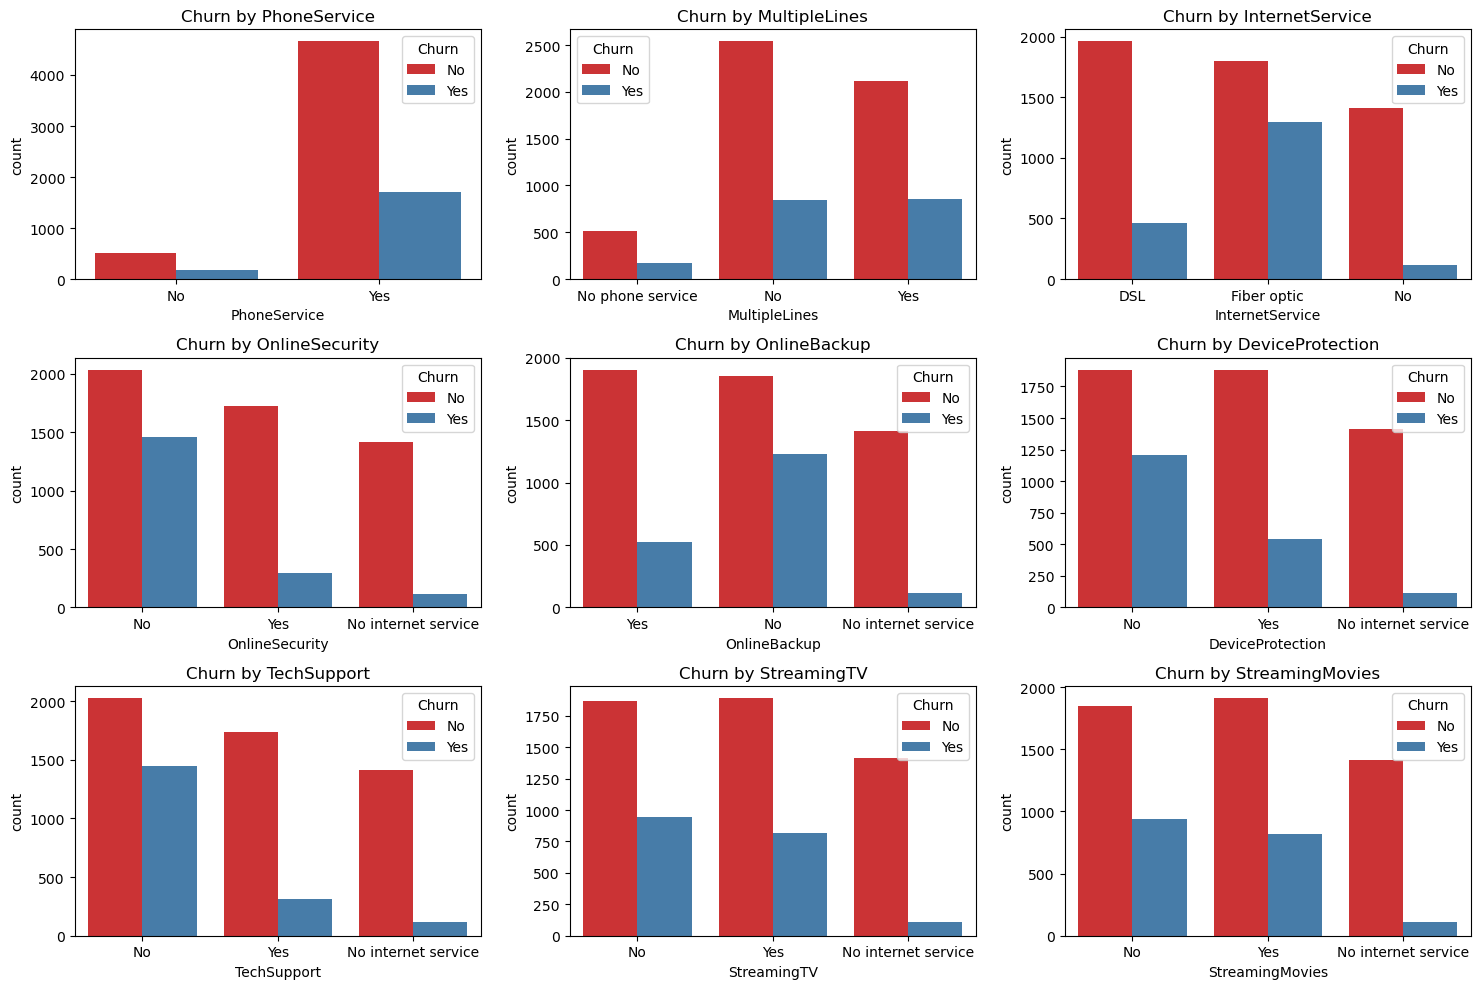

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i, col in enumerate(services_cols):
    r, c = i // 3, i % 3
    sns.countplot(
        data=df, x=col, hue='Churn',
        ax=axes[r, c], palette='Set1'
    ).set_title(f'Churn by {col}')

plt.tight_layout()
plt.show()

**2. Services Subscribed vs Churn**
* `Fiber optic` users have an alarmingly high churn rate.
* Customers lacking value-added services (`TechSupport`, `OnlineSecurity`, `OnlineBackup`) are highly vulnerable to leaving.

#### ==========================================
#### --- 3. Account Information vs Churn ---
#### ==========================================

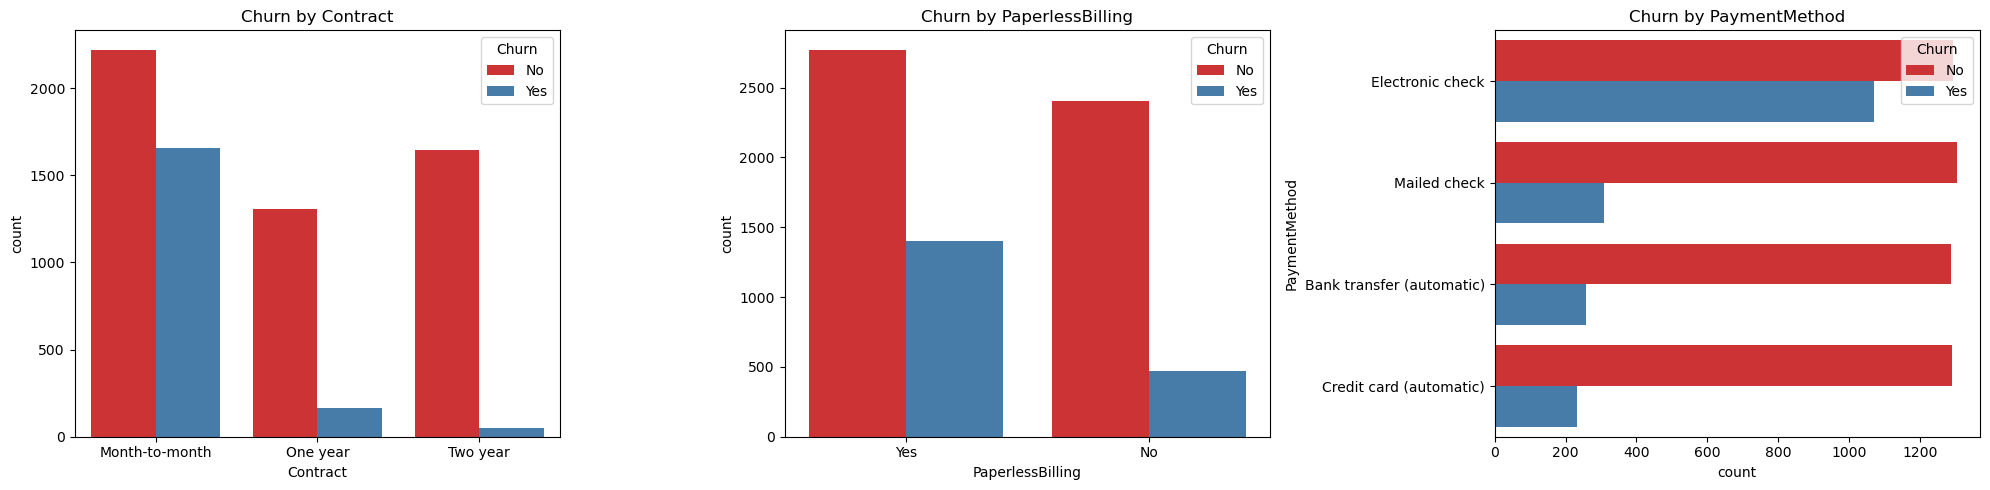

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20,5))

for i, col in enumerate(account_cols):
    if col == 'PaymentMethod':
        sns.countplot(
            data=df, y=col, hue='Churn',
            ax=axes[i], palette='Set1'
        ).set_title(f'Churn by {col}')
    else:
        sns.countplot(
            data=df, x=col, hue='Churn',
            ax=axes[i], palette='Set1'
        ).set_title(f'Churn by {col}')

plt.tight_layout()
plt.show()

**3. Account Information vs Churn**
* `Contract`: Month-to-month contracts drive the highest churn.
* `PaymentMethod`: Electronic check users are highly prone to churning.

#### ==========================================
#### --- 4. Numerical Variables vs Churn ---
#### ==========================================

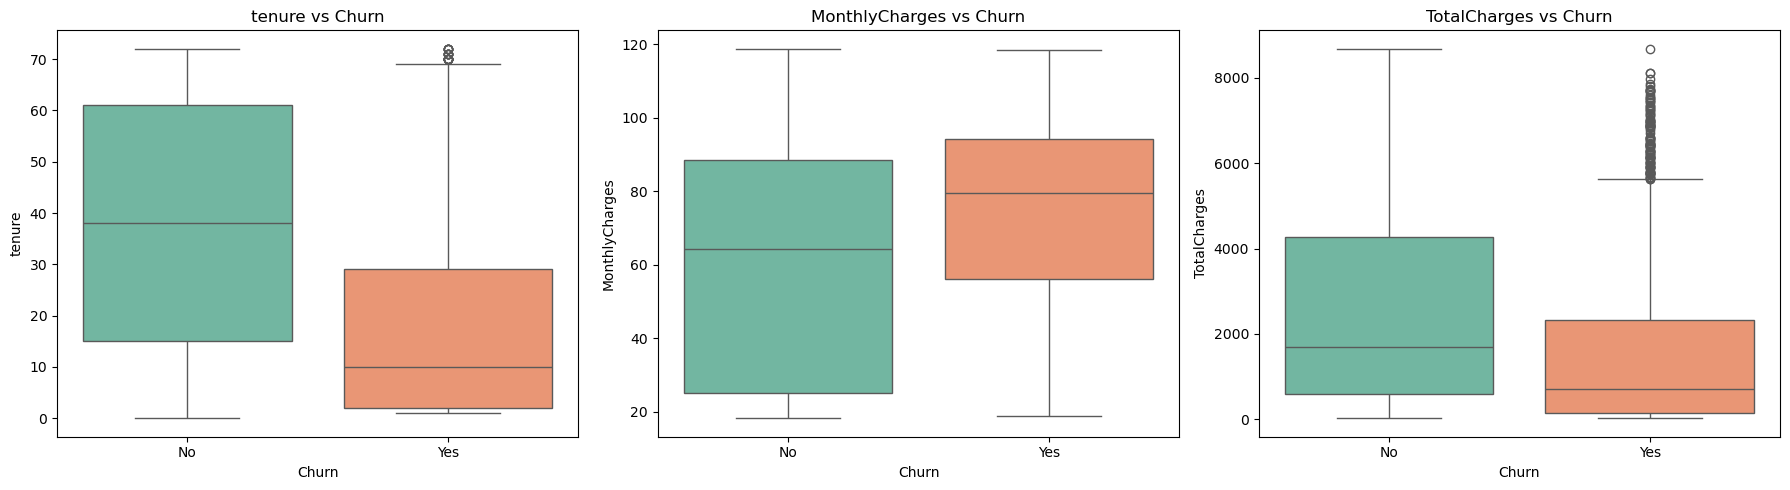

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, x='Churn', y=col, hue='Churn',
        palette='Set2', ax=axes[i], legend=False
    ).set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

**2. Bivariate Analysis (Numerical vs Churn)**
* `tenure` vs Churn: Churned customers typically have a much lower tenure. The longer a customer stays, the less likely they are to churn.
* `MonthlyCharges` vs Churn: Customers who leave tend to have higher median monthly charges compared to those who stay.
* `TotalCharges` vs Churn: Churned customers generally have lower total charges, which aligns with them having lower tenure (leaving early before accumulating high charges).

### 3️⃣ Multivariate Analysis
In this section, we analyze the interactions between three or more variables simultaneously to uncover deeper patterns and correlations that might not be visible in bivariate analysis.

#### ==========================================
#### --- 1. Multivariate Categorical vs Numerical ---
#### ==========================================َ

Text(0.5, 1.0, 'Monthly Charges vs Internet Service by Churn')

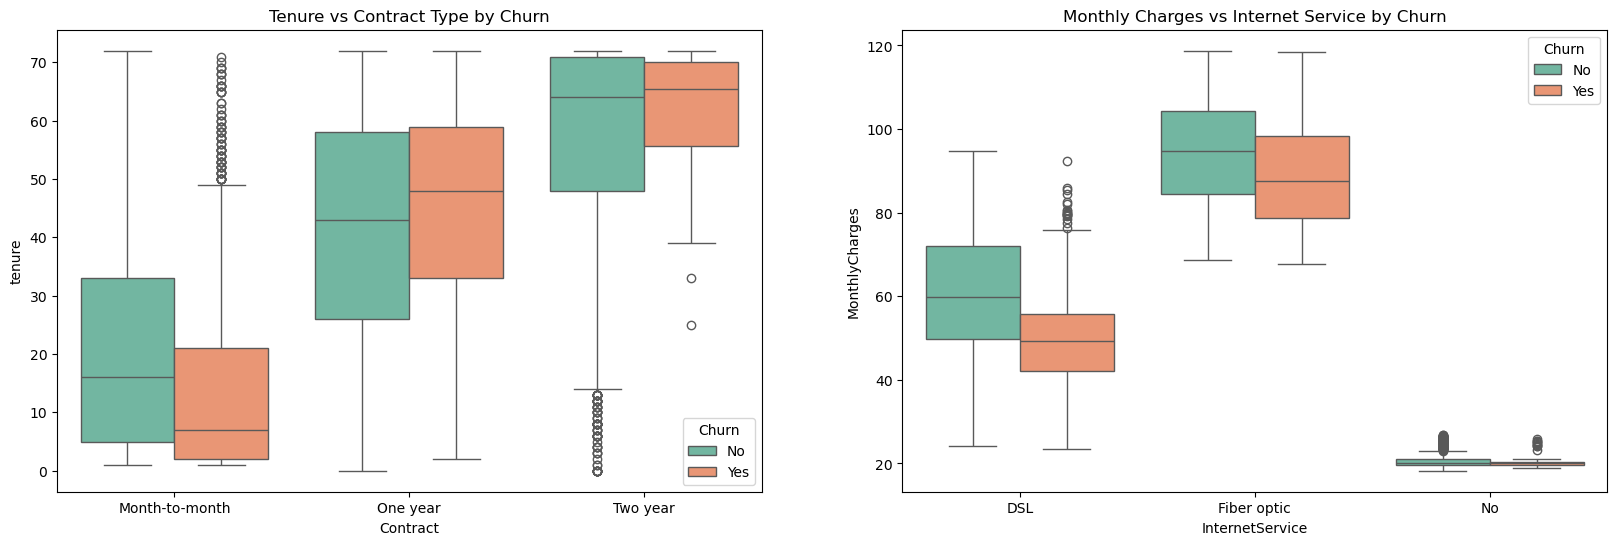

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Tenure vs Contract by Churn
sns.boxplot(
    data=df, x='Contract', y='tenure', hue='Churn',
    ax=axes[0], palette='Set2'
).set_title('Tenure vs Contract Type by Churn')

# MonthlyCharges vs InternetService by Churn
sns.boxplot(
    data=df, x='InternetService', y='MonthlyCharges', hue='Churn',
    ax=axes[1], palette='Set2'
).set_title('Monthly Charges vs Internet Service by Churn')

**1. Tenure, Contract Type, and Churn**
* Customers on `Month-to-month` contracts tend to churn very early (low median tenure).
* Even for `One year` or `Two year` contracts, the customers who do end up churning typically have a lower tenure than those who stay, but their tenure is still much higher than the month-to-month churners.

**2. Monthly Charges, Internet Service, and Churn**
* `Fiber optic` users have the highest monthly charges. Within this group, the ones who churn tend to pay even higher median charges than those who stay, indicating high price sensitivity.
* `DSL` users pay significantly less, and the price difference between churners and non-churners in this group is minimal.

#### ==========================================
#### --- 2. Correlation Matrix (Heatmap) ---
#### ==========================================

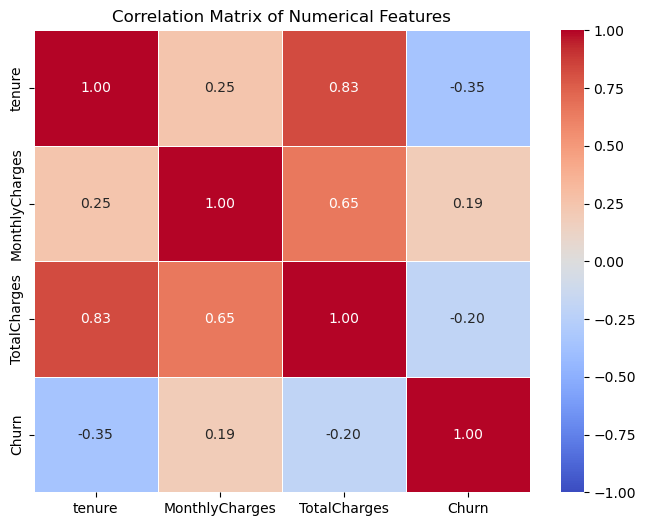

In [28]:
plt.figure(figsize=(8, 6))
correlation_matrix = correlation_df.corr()

sns.heatmap(
    correlation_matrix, annot=True, cmap='coolwarm', 
    fmt='.2f', linewidths=0.5, vmin=-1, vmax=1
).set_title('Correlation Matrix of Numerical Features')

plt.show()

**2. Correlation Matrix (Numerical Features)**
* We use a heatmap to check for multicollinearity among numerical variables.
* `TotalCharges` is highly correlated with both `tenure` and `MonthlyCharges` (which makes perfect sense, as Total = Monthly * Tenure). We might need to handle this high collinearity during model building.

#### ==========================================
#### --- Advanced Bivariate: Tenure Binning ---
#### ==========================================

### ⏳ Tenure Binning & Analysis
Numerical `tenure` can be noisy. By converting `tenure` (in months) into categorical bins (Years), we can observe clearer trends.

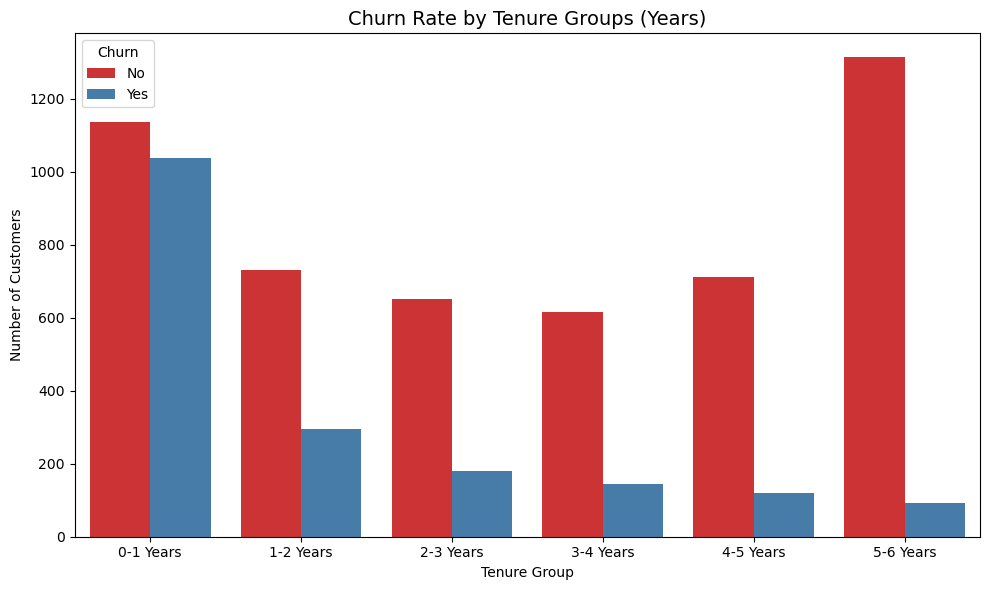

In [29]:
# Create bins for tenure (12 months = 1 year)
labels = ['0-1 Years', '1-2 Years', '2-3 Years', '3-4 Years', '4-5 Years', '5-6 Years']
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, 72], labels=labels)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, x='tenure_group', hue='Churn', 
    palette='Set1'
).set_title('Churn Rate by Tenure Groups (Years)', fontsize=14)

plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Insights from Tenure Groups:**
* The churn rate is massively concentrated in the **0-1 Years** group.
* As customers cross the 1-year mark, the probability of them leaving drops drastically. The most loyal customers are in the 5-6 years bracket with an extremely low churn rate.

#### =========================================
#### --- Advanced Multivariate: Scatter Plots ---
#### ==========================================

### 🌌 Scatter Plot Analysis (Numerical Interactions)
Scatter plots help us visualize the relationship between two continuous variables and see where the churned customers are clustered.

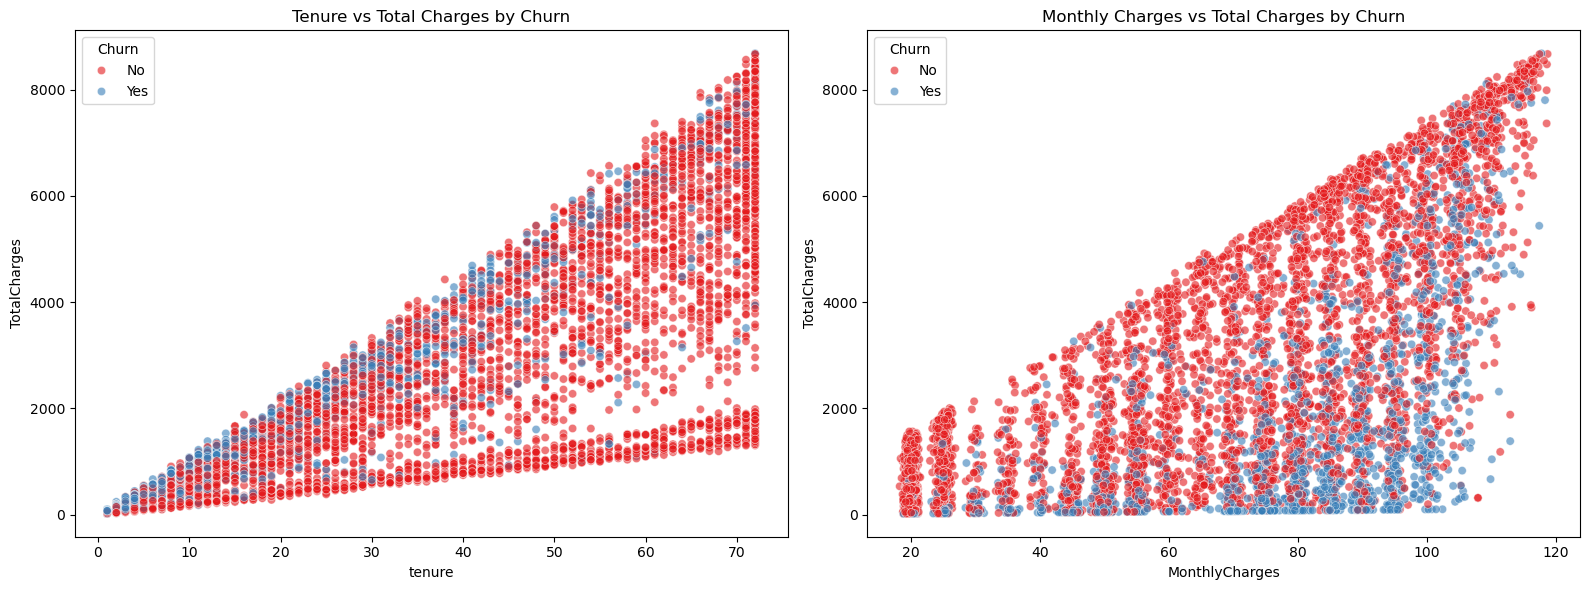

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter 1: Tenure vs Total Charges
sns.scatterplot(
    data=df, x='tenure', y='TotalCharges', hue='Churn', 
    palette='Set1', alpha=0.6, ax=axes[0]
).set_title('Tenure vs Total Charges by Churn')

# Scatter 2: Monthly Charges vs Total Charges
sns.scatterplot(
    data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', 
    palette='Set1', alpha=0.6, ax=axes[1]
).set_title('Monthly Charges vs Total Charges by Churn')

plt.tight_layout()
plt.show()

**Insights from Scatter Plots:**
1. **Tenure vs Total Charges:** There is a clear linear relationship (as tenure increases, total charges increase). Churned customers (red dots) are heavily clustered at the bottom-left corner (low tenure, low total charges). 
2. **Monthly Charges vs Total Charges:** Churned customers with high monthly charges leave the service quickly, preventing them from reaching high total charges. You can see a dense red cluster at the higher end of the monthly charges axis but lower end of the total charges axis.

#### ==========================================
#### --- Total Services vs Churn ---
#### ==========================================

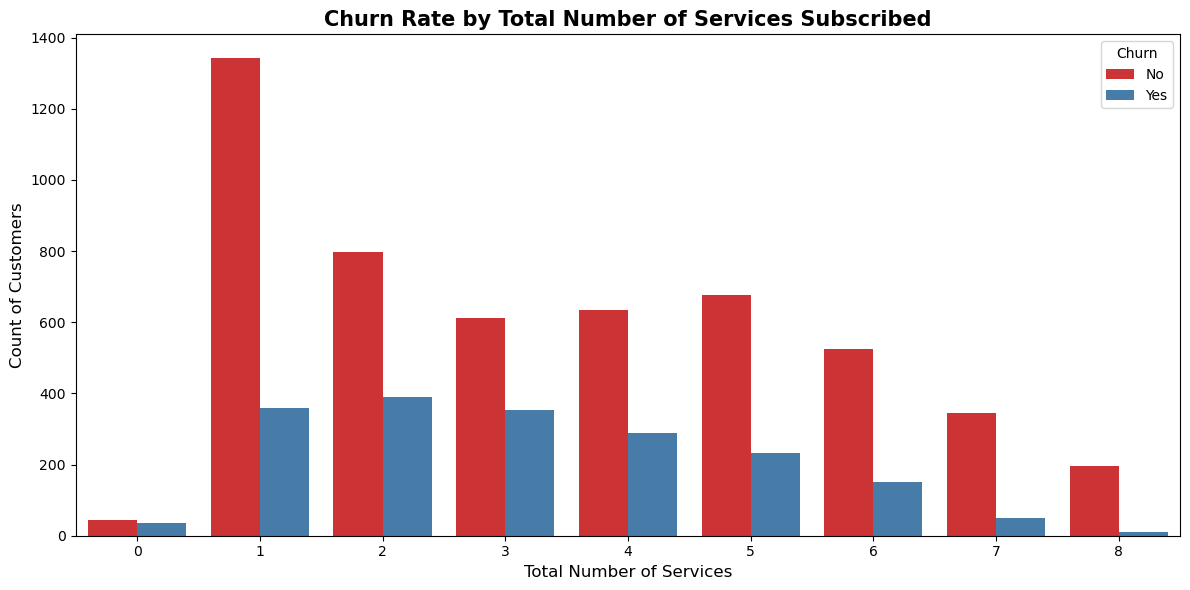

In [ ]:


# 1. Define the service columns we want to count
service_columns = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 
    'StreamingTV', 'StreamingMovies'
]

# 2. Create the new feature: sum of 'Yes' in the service columns for each customer
df['Total_Services'] = (df[service_columns] == 'Yes').sum(axis=1)

# 3. Plot the new feature against Churn
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df, x='Total_Services', hue='Churn', 
    palette='Set1'
).set_title('Churn Rate by Total Number of Services Subscribed', fontsize=15, fontweight='bold')

plt.xlabel('Total Number of Services', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)
plt.legend(title='Churn', loc='upper right')
plt.tight_layout()
plt.show()

## 🏆 Final EDA Report: Conclusions & Recommendations

### 💡 1. Key Business Conclusions (What the data tells us)
* **Early Attrition:** The vast majority of churn occurs in the first 0-12 months.
* **The Fiber Optic Issue:** `Fiber optic` users have an unusually high churn rate despite paying premium prices, indicating potential quality or pricing dissatisfaction.
* **Commitment Level:** Customers on `Month-to-month` contracts and those paying via `Electronic check` are the most likely to leave.
* **Lack of Support:** The absence of value-added services (`TechSupport`, `OnlineSecurity`, `OnlineBackup`) leaves customers highly vulnerable to churning.
* **Vulnerable Demographics:** Independent customers (no partner/dependents) and Senior Citizens show higher tendencies to churn.


### 🎯 2. Actionable Recommendations (What the business should do)

**1. Revamp the "First-Year" Onboarding:**
* **Action:** Target the 0-1 year churn window.
* **Tactic:** Implement proactive check-in calls at months 1, 3, and 6. Offer a loyalty reward or free service upgrade at the 6-month mark to push them past the critical first-year threshold.

**2. Audit Fiber Optic Quality & Pricing:**
* **Action:** Stop the leak of high-paying `Fiber optic` customers.
* **Tactic:** Conduct immediate technical performance audits and run targeted satisfaction surveys. Compare pricing with competitors and consider restructuring tiers if necessary.

**3. Incentivize Long-Term Commitment:**
* **Action:** Shift customers away from risky `Month-to-month` contracts and `Electronic checks`.
* **Tactic:** Launch campaigns offering a 10% discount on the monthly bill or a free month of service if the customer upgrades to a 1-year contract and sets up auto-pay (Credit Card/Bank Transfer).

**4. Bundle Support Services:**
* **Action:** Increase the adoption of `TechSupport` and security features.
* **Tactic:** Offer a "Security & Support Bundle" free for the first 3 months to new internet subscribers to deeply integrate them into the ecosystem.

**5. Tailor Packages for Demographics:**
* **Action:** Retain Seniors and independent customers.
* **Tactic:** Create simplified, discounted "Senior Plans" with premium support. For single customers, offer attractive bundles (like Streaming add-ons) to increase the perceived value of their subscription.